In [1]:
using Pkg

Pkg.activate("..") # From demos/ we go one level up to the project root
#Pkg.instantiate()  # Optional, but recommended to ensure all dependencies are installed

using Printf
using MiniOps
using Random
using LinearAlgebra
using Plots
using Random 
using SeisProcessing


  Activating project at `~/Dropbox/MiniOps`


(256, 128)

ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     2.429760e+01     2.951868e+02
      20     1.465713e-02     3.561330e-01     5.174545e+00
      40     1.428857e-02     3.471780e-01     4.419741e+00
      60     1.405674e-02     3.415451e-01     3.899736e+00
      80     1.397850e-02     3.396441e-01     3.519020e+00
     100     1.394670e-02     3.388714e-01     3.242234e+00
     120     1.393153e-02     3.385029e-01     3.038638e+00
     140     1.378720e-02     3.349960e-01     2.896754e+00
     160     1.362962e-02     3.311670e-01     2.802945e+00
     180     1.348496e-02     3.276523e-01     2.741462e+00
     200     1.335539e-02     3.245039e-01     2.703018e+00
     220     1.322657e-02     3.213740e-01     2.680676e+00
     240     1.311327e-02     3.186211e-01     2.666612e+00
     260     1.301847e-02     3.163175e-01     2.656089e+00
     280     1.293728e

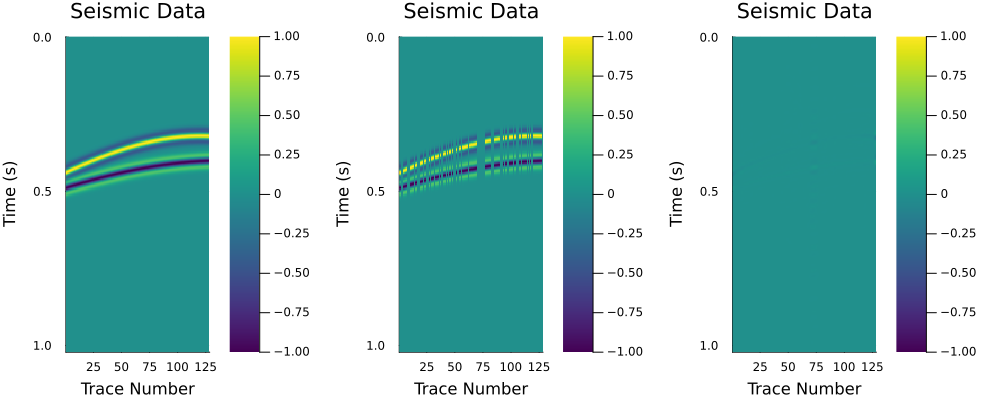

In [2]:
d = SeisHypEvents(nt=256, nx=128, dx = 10.0, vel=[4000.0,5000.0], tau=[0.32,0.40],apex=[200.0,400.0],amp=[1.0,-1.0]); println(size(d))
amax = maximum(abs.(d))
nt, nx = size(d)
dt = 0.004
t = (0:nt-1) .* dt

ns = 80; idx = sort(randperm(nx)[1:ns])


R = sampling_op(idx, (nt,nx)) 
p = 32
P = pad_op((nt,nx),(p,p), (p,p))
y = R*d 

F = fft_op(zeros(ComplexF64,nt+2p,nx+2p)) 
A = R*P'*F; 

  e = opnorm_power(A,randn(ComplexF64,nt+2p,nx+2p)) # Max eigen of C'C 
  ν = 0.98/e^2.  # Step size 
  x2 = ista(A, y, zeros(ComplexF64,nt+2p,nx+2p), 0.003, ν; niter=300, verbose=true);
  drec = real.(P'*F*x2)


p1 = heatmap(
    1:nx, t, d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax, amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)

p2 = heatmap(
    1:nx, t, R'*R*d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax,amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)

p3 = heatmap(
    1:nx, t, drec-d;
    xlabel = "Trace Number",
    ylabel = "Time (s)",
    title = "Seismic Data",
    color = :viridis,
    clims = (-amax,amax),
    yflip = true,
    aspect_ratio = :auto,
    xticks = 0:25:nx-1,
    yticks = 0:0.5:t[end],
)


plot(p1, p2,p3,layout = (1, 3), size = (1000, 400), margins =  4Plots.mm)


In [4]:
d = SeisParabEvents(nt=256, nx1=32, nx2=34, p1=[0.1,2.], p2=[2.3,-0.1], tau=[0.32,0.40],amp=[1.0,-1.0]); println(size(d))

(256, 32, 34)


In [12]:

amax = maximum(abs.(d))
nt, nx, ny = size(d)
dt = 0.004
t = (0:nt-1) .* dt

ns = 800; idx = sort(randperm(nx*ny)[1:ns])


R = sampling_op(idx, (nt,nx,ny)) 
pt, px, py= (16,4,4)
P = pad_op((nt,nx,ny),(pt,px,py), (pt,px,py))
y = R*d 
d0 = R'*y

F = fft_op(zeros(ComplexF64,nt+2*pt,nx+2*px,ny+2*py)) 
A = R*P'*F; 

  e = opnorm_power(A,randn(ComplexF64,nt+2*pt,nx+2*px,ny+2*py)) # Max eigen of C'C 
  ν = 0.98/e^2.  # Step size 
  x2 = ista(A, y, zeros(ComplexF64,nt+2*pt,nx+2*px,ny+2*py), 0.006, ν; niter = 200, verbose=true);
  drec = real.(P'*F*x2);



ISTA
    iter     rel_residual         residual             cost
------------------------------------------------------------
       0     1.000000e+00     7.721105e+01     2.980773e+03
      20     2.503754e-02     1.933175e+00     7.242851e+01
      40     2.471778e-02     1.908486e+00     5.859870e+01
      60     2.444083e-02     1.887102e+00     5.223392e+01
      80     2.406558e-02     1.858128e+00     4.947470e+01
     100     2.373115e-02     1.832307e+00     4.841018e+01
     120     2.352935e-02     1.816726e+00     4.793470e+01
     140     2.342808e-02     1.808907e+00     4.766113e+01
     160     2.336911e-02     1.804354e+00     4.748660e+01
     180     2.333293e-02     1.801560e+00     4.736579e+01
     200     2.330569e-02     1.799456e+00     4.727441e+01


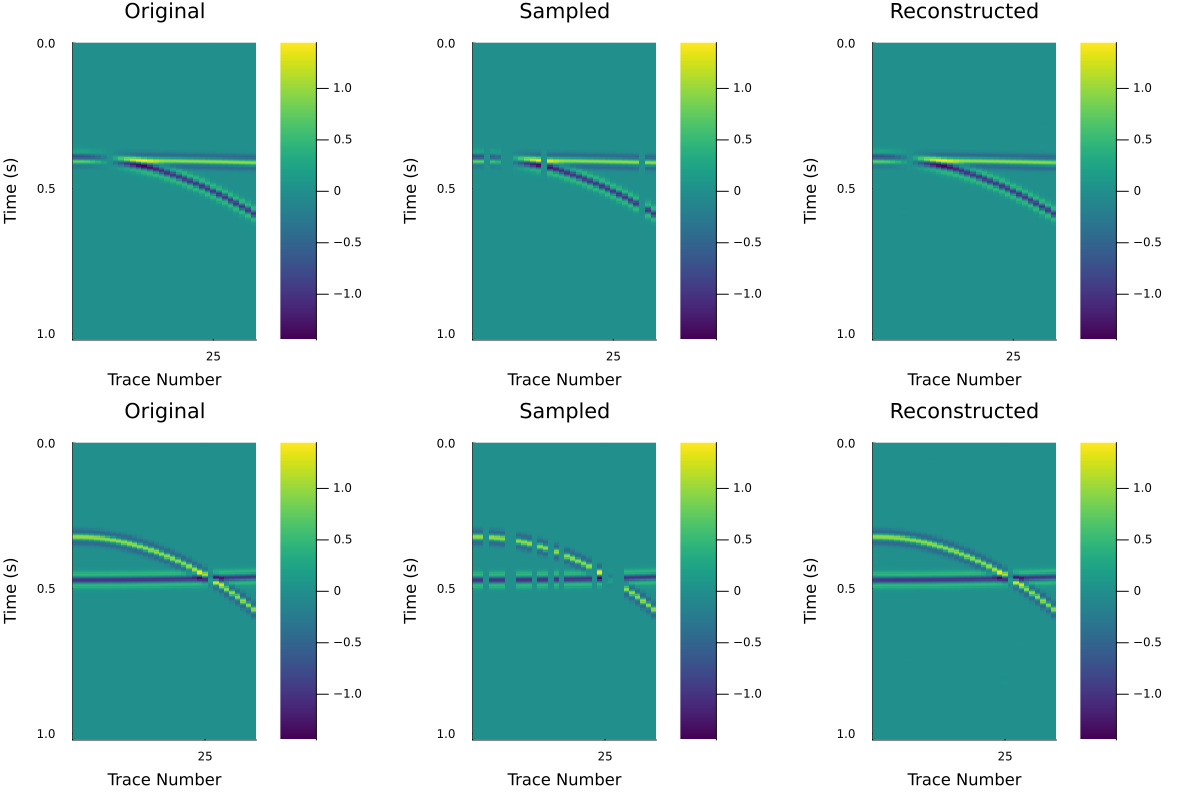

In [13]:
function seismic_plot(x; title="Seismic Data")
    nt,nx=size(x) 
    heatmap(
        1:nx, t, x;
        xlabel = "Trace Number",
        ylabel = "Time (s)",
        title = title,
        color = :viridis,
        clims = (-amax, amax),
        yflip = true,
        aspect_ratio = :auto,
        xticks = 0:25:nx-1,
        yticks = 0:0.5:t[end],
    )
end
p1 = seismic_plot(d[:, :, 20];    title="Original")
p2 = seismic_plot(d0[:, :, 20];   title="Sampled")
p3 = seismic_plot(drec[:, :, 20]; title="Reconstructed")
p4 = seismic_plot(d[:, 20, :];    title="Original")
p5 = seismic_plot(d0[:, 20, :];   title="Sampled")
p6 = seismic_plot(drec[:,20, :]; title="Reconstructed")
plot(p1, p2, p3, p4, p5, p6; layout=(2,3), size=(1200,800), margins=4Plots.mm)

In [14]:
snr = 20*log10(norm(d)/norm(d-drec))

29.05041750290785